In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Show plots inline in Jupyter
%matplotlib inline

# Load datasets (adjust the paths if needed)
past = pd.read_csv("newPastCBB.csv")
curr = pd.read_csv("cbb25.csv")

past.head()


,Unnamed: 0,Team,Conf,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,...,3P%D,3PR,3PRD,ADJ_T,WAB,Win%,Year,TeamText,matched_official_team,LostTo
0,0,2011_Ohio_St_,B10,37,34,126.010,91.811,0.97421,56.3200,48.3126,...,34.0147,32.7171,34.6231,63.8246,11.710,0.918919,2011,Ohio St,Ohio St,2011_Kentucky
1,1,2011_Kansas,B12,38,35,120.940,91.060,0.96332,57.0100,44.5110,...,29.8900,32.4179,34.6231,68.0480,10.220,0.921053,2011,Kansas,Kansas,2011_VCU
2,2,2011_Duke,ACC,37,32,120.650,91.580,0.96003,53.7170,44.5110,...,32.4580,35.3113,24.5500,68.5380,9.330,0.864865,2011,Duke,Duke,2011_Arizona
3,3,2011_Texas,B12,36,28,115.521,90.020,0.94604,50.2108,42.5300,...,29.5600,25.5324,26.1120,65.5157,5.413,0.777778,2011,Texas,Texas,2011_Arizona
4,4,2011_Kentucky,SEC,38,29,119.370,93.422,0.94375,52.3410,44.2900,...,32.4580,32.4179,29.7720,64.8191,5.215,0.763158,2011,Kentucky,Kentucky,2011_Connecticut


In [2]:
# Features to use
feature_cols = [
    "G", "W", "ADJOE", "ADJDE", "BARTHAG", "EFG_O", "EFG_D", "TOR", "Seed",
    "TORD", "ORB", "DRB", "FTR", "FTRD", "2P%", "2P%D", "3P%", "3P%D",
    "3PR", "3PRD", "ADJ_T", "WAB",
]

# Keep only rows with a valid LostTo team (exclude champion rows and NaNs)
mask_valid = (~past["LostTo"].isna()) & (past["LostTo"] != "Champion")
past_games = past[mask_valid].copy()

# Index past data by 'Team' for fast lookup
past_indexed = past.set_index("Team")

X_rows = []
y_rows = []  # 1 = first team wins, 0 = first team loses

skipped = 0

for idx, row in past_games.iterrows():
    team1_name = row["Team"]
    opp_name = row["LostTo"]

    # If we can't find the opponent at all, skip this row
    if opp_name not in past_indexed.index:
        skipped += 1
        continue

    opp_rows = past_indexed.loc[opp_name]

    # Handle possible multiple seasons for the same opponent team
    if isinstance(opp_rows, pd.DataFrame):
        if "Year" in past.columns:
            # Try to match the same year
            year = row.get("Year", None)
            if year is not None:
                opp_rows_year = opp_rows[opp_rows["Year"] == year]
                if len(opp_rows_year) > 0:
                    opp_row = opp_rows_year.iloc[0]
                else:
                    opp_row = opp_rows.iloc[0]
            else:
                opp_row = opp_rows.iloc[0]
        else:
            opp_row = opp_rows.iloc[0]
    else:
        opp_row = opp_rows

    # Make sure both rows have all required feature columns
    if not set(feature_cols).issubset(row.index) or not set(feature_cols).issubset(opp_row.index):
        skipped += 1
        continue

    # First direction: (team1 vs opponent) – in the tournament row, team1 LOST
    diff1 = row[feature_cols].values - opp_row[feature_cols].values
    X_rows.append(diff1)
    y_rows.append(0)  # team1 lost

    # Second direction: (opponent vs team1) – opponent WON
    diff2 = opp_row[feature_cols].values - row[feature_cols].values
    X_rows.append(diff2)
    y_rows.append(1)  # first team in this direction (opponent) won

X = np.vstack(X_rows)
y = np.array(y_rows)

print("Matchup dataset shape:", X.shape)
print("Class balance (0 = first team loses, 1 = first team wins):", np.bincount(y))
print("Skipped rows due to missing opponent/columns:", skipped)


Matchup dataset shape: (1470, 22)
Class balance (0 = first team loses, 1 = first team wins): [735 735]
Skipped rows due to missing opponent/columns: 328


In [3]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# XGBoost binary classifier for matchup outcomes
xgb_model = xgb.XGBClassifier(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

accuracy = (y_pred == y_test).mean()
print(f"Accuracy: {accuracy:.3f}\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["first team loses", "first team wins"],
        zero_division=0,  # avoid undefined metric warnings
    )
)


Accuracy: 0.856

                  precision    recall  f1-score   support

first team loses       0.87      0.84      0.85       184
 first team wins       0.85      0.87      0.86       184

        accuracy                           0.86       368
       macro avg       0.86      0.86      0.86       368
    weighted avg       0.86      0.86      0.86       368



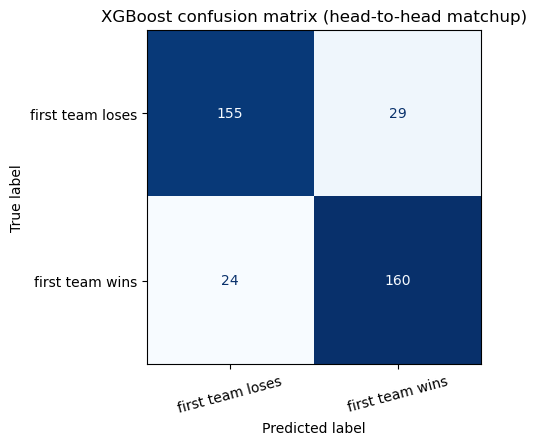

In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["first team loses", "first team wins"],
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("XGBoost confusion matrix (head-to-head matchup)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


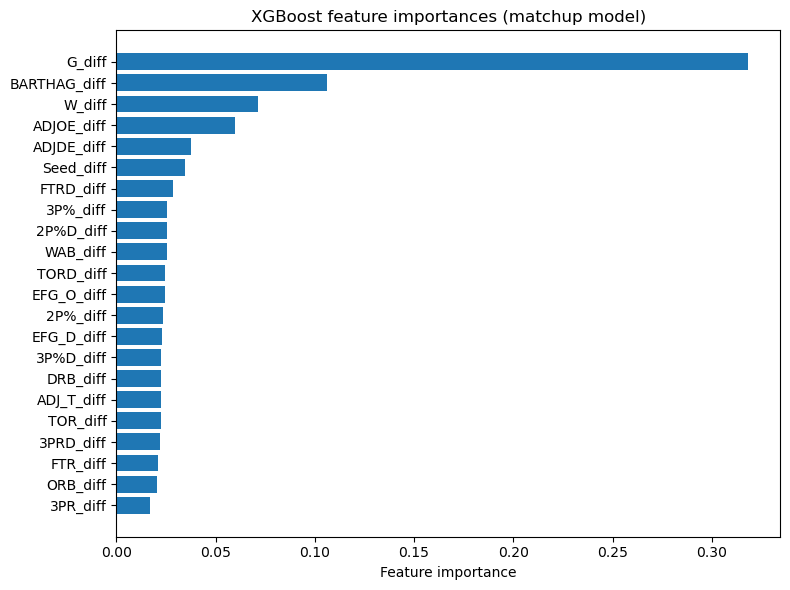

In [6]:
# Feature importances for the difference-based features
feature_names = [f"{c}_diff" for c in feature_cols]

importances = xgb_model.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.array(feature_names)[sorted_idx], importances[sorted_idx])
ax.set_xlabel("Feature importance")
ax.set_title("XGBoost feature importances (matchup model)")
plt.tight_layout()
plt.show()


In [ ]:
# Current season teams (from cbb25.csv)
current_teams = curr.copy()

def find_team_row(name, df=current_teams):
    """
    Return the row in df for the team named `name`.

    Priority:
    1. Exact match on 'Team' (case-insensitive).
    2. If no exact match, fallback to substring search (case-insensitive).
    If multiple matches remain, print a warning and use the first.
    """
    name_clean = name.strip().lower()

    # 1) Exact match on 'Team'
    exact_mask = df["Team"].str.strip().str.lower() == name_clean
    exact_matches = df[exact_mask]

    if len(exact_matches) == 1:
        return exact_matches.iloc[0]
    elif len(exact_matches) > 1:
        print(f"Warning: multiple EXACT matches for '{name}'. Using the first one:")
        print(exact_matches["Team"].tolist())
        return exact_matches.iloc[0]

    # 2) Fallback: substring search (non-regex, case-insensitive)
    mask = df["Team"].str.contains(name, case=False, na=False, regex=False)
    matches = df[mask]

    if len(matches) == 0:
        raise ValueError(f"No team found matching '{name}'.")

    if len(matches) > 1:
        print(f"Warning: multiple teams match '{name}'. Using the first one:")
        print(matches["Team"].tolist())

    return matches.iloc[0]


In [ ]:
def predict_game(team1, team2, model=xgb_model, df=current_teams, feature_cols=feature_cols):
    """
    Predict the winner of a head-to-head matchup between two teams in an
    order-invariant way by evaluating the model in both directions.

    Parameters
    ----------
    team1, team2 : str
        Substrings or full names of the teams as listed in the cbb25.csv 'Team' column.

    Returns
    -------
    winner_name : str
        The team name predicted to win.
    """
    # Look up the two teams in the current-season data
    row1 = find_team_row(team1, df)
    row2 = find_team_row(team2, df)

    team1_full = row1["Team"]
    team2_full = row2["Team"]

    x1 = row1[feature_cols].values.astype(float)
    x2 = row2[feature_cols].values.astype(float)

    # Diff in both directions
    diff_12 = x1 - x2  # team1 - team2
    diff_21 = x2 - x1  # team2 - team1

    # Make sure we use the correct probability column for class "1" (first team wins)
    class_idx_win = np.where(model.classes_ == 1)[0][0]

    # P(first team wins) in each ordering
    p1 = model.predict_proba(diff_12.reshape(1, -1))[0][class_idx_win]  # P(team1 wins | order (team1, team2))
    p2 = model.predict_proba(diff_21.reshape(1, -1))[0][class_idx_win]  # P(team2 wins | order (team2, team1))

    # Enforce symmetry: average the two perspectives
    P_team1 = (p1 + (1.0 - p2)) / 2.0
    P_team2 = 1.0 - P_team1

    if P_team1 >= P_team2:
        winner_name = team1_full
        loser_name = team2_full
    else:
        winner_name = team2_full
        loser_name = team1_full

    print(f"Matchup: {team1_full} vs {team2_full}")
    print(f"P({team1_full} wins) ≈ {P_team1:.3f}")
    print(f"P({team2_full} wins) ≈ {P_team2:.3f}")
    print()
    print(f"Predicted winner: {winner_name} over {loser_name}")

    return winner_name


In [ ]:
predict_game("florida", "houston")
